# Project: Neural Estate
### Datum: 2026-05-05
### Teamleden: Michal Kakol (24087068), Sem Ooms (23091789), Chaimae

# 1. Setup:

In [1]:
import sys
import os

sys.path.insert(0, os.path.abspath(".."))
from functions.main import *# Run initialization
cfg = Config()
os.makedirs(cfg.CHECKPOINT_DIR, exist_ok=True)
dm = DatasetManager(cfg)
print("Train size:", len(dm.train_df), "| Val size:", len(dm.val_df))
print("Train distribution:")
print(dm.train_df['genre'].value_counts())
print("Val distribution:")
print(dm.val_df['genre'].value_counts())

ValueError: numpy.dtype size changed, may indicate binary incompatibility. Expected 96 from C header, got 88 from PyObject

In [ ]:
cfg = Config()
os.makedirs(cfg.CHECKPOINT_DIR, exist_ok=True)
dm = DatasetManager(cfg)
print("Train size:", len(dm.train_df), "| Val size:", len(dm.val_df))
print("Train distribution:")
print(dm.train_df['genre'].value_counts())
print("Val distribution:")
print(dm.val_df['genre'].value_counts())

NameError: name 'Config' is not defined

# 2. EDA:

De dataset bevat 429 trainingsamples en 108 validatiesamples, waarbij de genres rock, pop en hiphop de grootste klassen vormen en blues het minst voorkomt in zowel de train- als val-distributie. Bij de audioanalyse is elk bestand ingeladen via librosa om de sampling frequency en exacte duration te verifiëren als een 1D NumPy array. Via de formule $t_i = \frac{i}{sfreq}$ is een tijdsvector berekend die bevestigt dat alle audiobestanden een uniform tijdsgrid hebben. Dit is essentieel voor de opbouw van vaste input matrices voor de deep learning netwerken. Voor de tekstuele analyse zijn de lyrics omgezet naar lowercase en ontdaan van leestekens. De boxplot van de token length per genre laat zien dat de mediaan overal onder de 1000 woorden ligt, maar hiphop en metal tonen extreme outliers met uitschieters tot wel 16.500 en 17.000 tokens. De top-5 meest voorkomende woorden per genre, gecorrigeerd voor stop words, laten specifieke patronen zien, zoals het woord 'boogie' bij disco, 'natalya' binnen de metal-data, 'jammin' bij reggae en 'baby' als top-woord bij blues en pop.

In het frequentiedomein is de Short-Time Fourier Transform (STFT) toegepast via librosa.stft. Volgens de wetten van Fourier kan elke complexe, ruizige akoestische golfvorm worden ontleend aan een optelling van sinusvouwen volgens de formule $y(t) = A \cdot \sin(2\pi ft + \phi)$. De complexe resultaten zijn omgezet naar decibelschaal via librosa.amplitude_to_db om spectrogrammen te genereren, waarbij de Nyquist criteria ($\frac{sfreq}{2}$) de fysieke grens vormt die aliasing voorkomt. De resulterende logaritmische spectrogrammen tonen duidelijke visuele verschillen in de energieverdeling per genre. Metal laat een dicht en verzadigd spectrum zien met constante hoge energie over bijna alle frequenties tot 4096 Hz, terwijl hiphop juist zeer regelmatige, scherpe verticale ritmische spikes toont rond de 64 Hz. Reggae en disco tonen ritmische patronen of vertical pulsing in de lagere registers, country toont een dichte horizontale band rond 64–128 Hz, en blues geeft een kalmer beeld met grote lege vlakken in de hogere frequenties. De Mel-schaal projecteert deze data zo dat het aansluit bij de menselijke auditieve perception door de nadruk te leggen op variaties in de lage frequenties, wat bewijzen levert dat deze spectrale eigenschappen sterke patronen bevatten voor classificatie.

In [ ]:
# Pipeline
explorer = DataExplorer(cfg, dm)
print("Audio samples")
explorer.display_audio_samples()
print("Audio properties")
explorer.analyze_audio_properties()
print("Lyrics")
explorer.analyze_lyrics()
print("Frequency domain")
explorer.analyze_frequency_domain()

NameError: name 'DataExplorer' is not defined

# 3. RNN voor Audio:

In dit onderdeel is een recurrent model ontwikkeld voor het classificeren van audio sequenties. Voor de feature engineering zijn 30 seconden audiofragmenten omgezet in log-scaled Mel-Spectrogram arrays. Er is gekozen voor een hop_length van 1024 om de tijd-as te comprimeren tot 650 frames, wat de computationele last voor de recurrente lagen vermindert. De spectrogrammen zijn genormaliseerd en geknipt naar een vast formaat van 650, 128. Tijdens de eerste testfase bleek het model een sterke bias te vertonen richting hiphop, waarbij veel andere genres foutief werden geclassificeerd. Dit probleem is opgelost door compute_class_weight te implementeren. Hiermee krijgt het model een gebalanceerde verliesfunctie, waardoor ondervertegenwoordigde genres zwaarder meewegen tijdens de training.

De architectuur bestaat uit een Keras Sequential model met een MaxPooling1D laag gevolgd door twee gestapelde Gated Recurrent Unit (GRU) lagen. De GRU structuur is belangrijk omdat het vanishing gradient fouten voorkomt die vaak optreden in traditionele RNN backpropagation loops. Waar standaard RNN's informatie verliezen door herhaalde fractionele vermenigvuldigingen, gebruiken GRU's Update en Reset gates om selectief historische data te bewaren of te verwijderen.

De resultaten na de aanpassingen tonen een verbetering in de spreiding van de voorspellingen, hoewel de validatie accuracy volatiel blijft rond de 40%. Uit de confusion matrix blijkt dat de eerdere hiphop-bias is verschoven naar pop, waarbij genres zoals reggae en rock vaak als pop worden aangezien. De training loss daalt consistent naar 1.5, maar de pieken in de validatie loss rond epoch 14 wijzen op instabiliteit in de optimalisatie. Metal en blues worden momenteel het meest betrouwbaar herkend, terwijl disco en reggae ondanks de class weights moeilijk te onderscheiden blijven voor het model op basis van deze spectrale features alleen. De ModelCheckpoint zorgt er gelukkig voor dat de best presterende configuratie voor de finale validatie behouden blijft.

Extracting training audio features
Extracting validation audio features
X_audio_train shape: (429, 650, 128) | X_audio_val shape: (108, 650, 128)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ max_pooling1d (MaxPooling1D)    │ (None, 325, 128)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru (GRU)                       │ (None, 325, 64)        │        37,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru_1 (GRU)                     │ (None, 64)             │        24,960 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 8)              │           264 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 64,552 (252.16 KB)

 Trainable params: 64,552 (252.16 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/20
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 176ms/step - accuracy: 0.1143 - loss: 2.1001
Epoch 1: val_loss improved from None to 2.06989, saving model to C:\Users\mkako\Portables\Projects\music_classification_dl\checkpoints\audio_gru_best.keras

Epoch 1: finished saving model to C:\Users\mkako\Portables\Projects\music_classification_dl\checkpoints\audio_gru_best.keras
14/14 ━━━━━━━━━━━━━━━━━━━━ 7s 244ms/step - accuracy: 0.1329 - loss: 2.0924 - val_accuracy: 0.2407 - val_loss: 2.0699
Epoch 2/20
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 172ms/step - accuracy: 0.1432 - loss: 2.0607
Epoch 2: val_loss improved from 2.06989 to 2.04846, saving model to C:\Users\mkako\Portables\Projects\music_classification_dl\checkpoints\audio_gru_best.keras

Epoch 2: finished saving model to C:\Users\mkako\Portables\Projects\music_classification_dl\checkpoints\audio_gru_best.keras
14/14 ━━━━━━━━━━━━━━━━━━━━ 3s 193ms/step - accuracy: 0.1562 - loss: 2.0560 - val_accuracy: 0.1574 - val_loss: 2.0485
Epoch 3/20
14/14 ━━━━━━━━━━

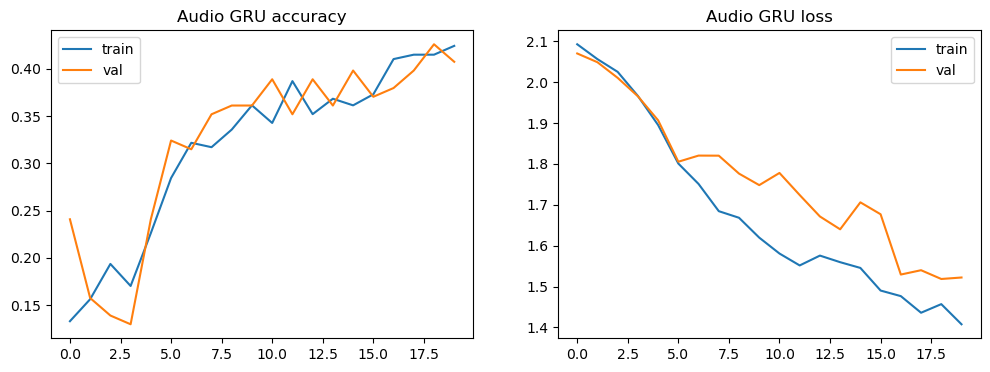

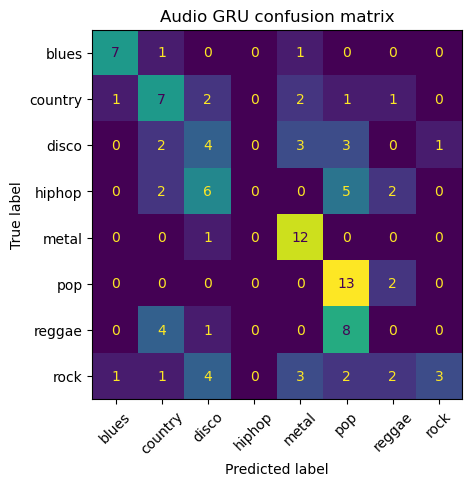

In [ ]:
import tensorflow as tf
tf.random.set_seed(cfg.SEED)
np.random.seed(cfg.SEED)
# Execution Pipeline
extractor = AudioFeatureExtractor(cfg)
print("Extracting training audio features")
X_audio_train = extractor.build_dataset(dm.train_df)
print("Extracting validation audio features")
X_audio_val = extractor.build_dataset(dm.val_df)

y_train = dm.train_df['label'].values
y_val = dm.val_df['label'].values
print("X_audio_train shape:", X_audio_train.shape, "| X_audio_val shape:", X_audio_val.shape)

gru_model = AudioGRUModel(cfg)
gru_model.model.summary()
history_gru = gru_model.train(X_audio_train, y_train, X_audio_val, y_val)

gru_model.model = keras.models.load_model(gru_model.checkpoint_path)
gru_val_proba = gru_model.model.predict(X_audio_val, verbose=0)
gru_val_preds = np.argmax(gru_val_proba, axis=1)
gru_val_acc = float(np.mean(gru_val_preds == y_val))
print("Audio GRU val accuracy:", gru_val_acc)

genre_labels = [cfg.IDX_TO_GENRE[i] for i in range(8)]
plot_history(history_gru, 'Audio GRU')
plot_cm(y_val, gru_val_preds, 'Audio GRU confusion matrix', genre_labels)

# 4. LSTM Model voor Lyrics:

Voor de tekstclassificatie is een pipeline opgezet die songteksten verwerkt tot numerieke sequenties. De TextPreprocessor class gebruikt een Keras Tokenizer om woorden om te zetten in integers. Om de trainingsstabiliteit te verbeteren, is de vocabulary verkleind naar 2000 woorden en is de truncating aangepast naar pre. De teksten zijn genormaliseerd door leestekens te verwijderen en alles naar lowercase te zetten. Via pad_sequences zijn alle fragmenten gelijkgetrokken naar een lengte van 300 tokens, wat zorgt voor een uniform inputformaat voor het netwerk.

Het model is opgebouwd als een Keras Sequential netwerk, beginnend met een Embedding laag. Deze laag zet tokens om in dense spatial vectors, waarbij de afstand tussen vectoren de semantische gelijkenis tussen woorden representeert, vergelijkbaar met Word2Vec. Er is gekozen voor een Many to One sequence. Hierbij verwerkt een enkele LSTM layer de hele reeks woorden om uiteindelijk een genre label te voorspellen via een Softmax activatie. Dit verschilt van Many To Many architecturen die gebruikt worden voor tekstgeneratie. Om de eerder geconstateerde extreme overfitting tegen te gaan, is de dropout verhoogd naar 0.6 en zijn de embedding dimensies verlaagd naar 32.

De resultaten laten zien dat het model stabieler traint, maar de validatie/accuracy blijft steken rond de 30%. Hoewel de extreme divergentie in de loss-curves is verminderd, blijft de confusion matrix problematisch. Er is een sterke bias zichtbaar waarbij veel genres, zoals country en rock, foutief worden gelabeled in de blues en hiphop categorieen. Dit suggereert dat lyrics voor deze kleine dataset een zwak signaal bevatten voor genre onderscheid. De bottleneck lijkt hier niet de architectuur te zijn, maar de beperkte hoeveelheid data en de overlap in woordgebruik tussen verschillende genres. Het model gebruikt nu class weights en EarlyStopping om de beste gewichten te behouden, maar de voorspellende kracht blijft beperkt door de kwaliteit van de beschikbare tekstuele data.

X_text_train shape: (429, 300) | X_text_val shape: (108, 300)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ (None, 300, 32)        │        64,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ (None, 32)             │         8,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 8)              │           264 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 72,584 (283.53 KB)

 Trainable params: 72,584 (283.53 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/15
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step - accuracy: 0.1497 - loss: 2.0718
Epoch 1: val_loss improved from None to 2.06351, saving model to C:\Users\mkako\Portables\Projects\music_classification_dl\checkpoints\lstm_best.keras

Epoch 1: finished saving model to C:\Users\mkako\Portables\Projects\music_classification_dl\checkpoints\lstm_best.keras
14/14 ━━━━━━━━━━━━━━━━━━━━ 3s 93ms/step - accuracy: 0.1515 - loss: 2.0775 - val_accuracy: 0.2593 - val_loss: 2.0635
Epoch 2/15
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 62ms/step - accuracy: 0.2291 - loss: 2.0556
Epoch 2: val_loss improved from 2.06351 to 2.04358, saving model to C:\Users\mkako\Portables\Projects\music_classification_dl\checkpoints\lstm_best.keras

Epoch 2: finished saving model to C:\Users\mkako\Portables\Projects\music_classification_dl\checkpoints\lstm_best.keras
14/14 ━━━━━━━━━━━━━━━━━━━━ 1s 75ms/step - accuracy: 0.2284 - loss: 2.0560 - val_accuracy: 0.2593 - val_loss: 2.0436
Epoch 3/15
13/14 ━━━━━━━━━━━━━━━━━━━━ 0s 60ms/step 

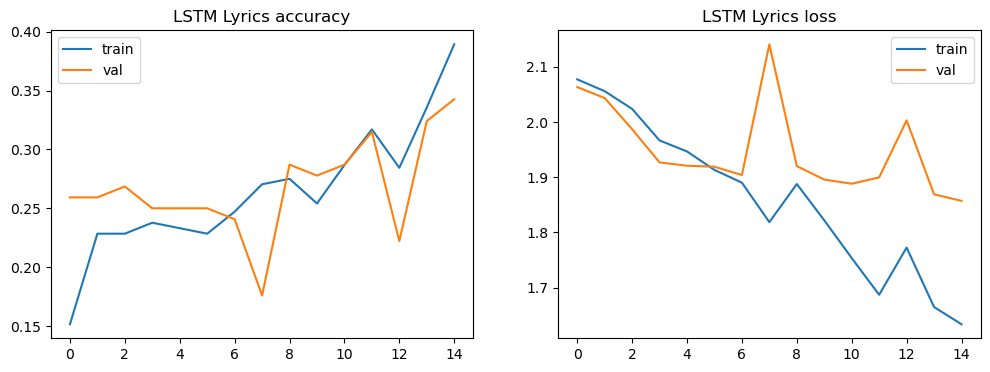

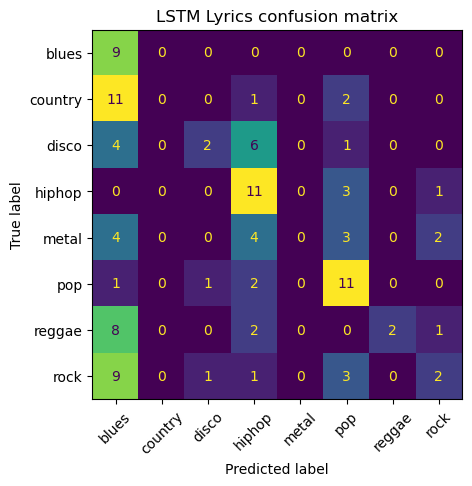

In [ ]:
tf.random.set_seed(cfg.SEED)
np.random.seed(cfg.SEED)
# Execution Pipeline
prep = TextPreprocessor()
prep.fit(dm.train_df['lyrics'])

X_text_train = prep.transform(dm.train_df['lyrics'])
X_text_val = prep.transform(dm.val_df['lyrics'])

y_train = dm.train_df['label'].values
y_val = dm.val_df['label'].values
print("X_text_train shape:", X_text_train.shape, "| X_text_val shape:", X_text_val.shape)

lstm_model = LSTMTextModel(cfg)
lstm_model.model.summary()
history_lstm = lstm_model.train(X_text_train, y_train, X_text_val, y_val)

lstm_model.model = keras.models.load_model(lstm_model.checkpoint_path)
lstm_val_proba = lstm_model.model.predict(X_text_val, verbose=0)
lstm_val_preds = np.argmax(lstm_val_proba, axis=1)
lstm_val_acc = float(np.mean(lstm_val_preds == y_val))
print("LSTM Lyrics val accuracy:", lstm_val_acc)

genre_labels = [cfg.IDX_TO_GENRE[i] for i in range(8)]
plot_history(history_lstm, 'LSTM Lyrics')
plot_cm(y_val, lstm_val_preds, 'LSTM Lyrics confusion matrix', genre_labels)

# 5. Transformer voor Songteksten:

Voor de tekstclassificatie is gebruikgemaakt van distilbert-base-uncased, een Encoder-based model dat gebruikmaakt van het Self-Attention mechanisme om contextuele relaties tussen woorden bidirectioneel te begrijpen. In tegenstelling tot Decoder-only modellen (zoals GPT), die gericht zijn op het genereren van tekst, is DistilBERT geoptimaliseerd voor het extraheren van betekenis, wat belangrijk is voor genre-classificatie. Het model is gefinetuned door de pre-trained gewichten via backpropagation aan te passen aan de specifieke woordenschat van deze muziek dataset. De data-pipeline is geoptimaliseerd door gebruik te maken van subword tokenization, waarbij woorden worden opgesplitst in kleinere eenheden om het vocabulaire compact te houden. Speciale markers zoals [CLS] worden toegevoegd om een geaggregeerde representatie van de gehele zin te bieden voor de classificatie head. De implementatie van DataCollatorWithPadding zorgt voor efficiënte batch-verwerking door teksten dynamisch op te vullen, wat de training versnelt. Door gebruik te maken van EarlyStopping en load_best_model_at_end wordt voorkomen dat het model overfit op de kleine dataset van 429 samples.

De uiteindelijke resultaten tonen een validatie accuracy van circa 58%, wat de hoogste score is van alle eerder geteste modellen. De confusion matrix laat een veel gebalanceerder beeld zien dan bij de LSTM, voor het eerst worden alle acht genres, inclusief blues en reggae, correct geidentificeerd. Hoewel er nog steeds verwarring bestaat tussen rock en country, bewijst dit resultaat dat de Transformer-architectuur veel krachtiger is in het vinden van subtiele tekstuele patronen in kleine datasets dan traditionele recurrente netwerken. De finale Logits zijn via een Softmax functie omgezet in expliciete kansverdelingen, wat een betrouwbaar beeld geeft van de zekerheid van het model per voorspelling.

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

[transformers] DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
classifier.bias         | MISSING    | 
pre_classifier.weight   | MISSING    | 
classifier.weight       | MISSING    | 
pre_classifier.bias     | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Map:   0%|          | 0/429 [00:00<?, ? examples/s]

Map:   0%|          | 0/108 [00:00<?, ? examples/s]

Epoch,Training Loss,Validation Loss,Accuracy
1,No log,1.965737,0.287037
2,1.932519,1.700440,0.407407
3,1.932519,1.591455,0.472222


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Map:   0%|          | 0/108 [00:00<?, ? examples/s]

DistilBERT val accuracy: 0.4722222222222222


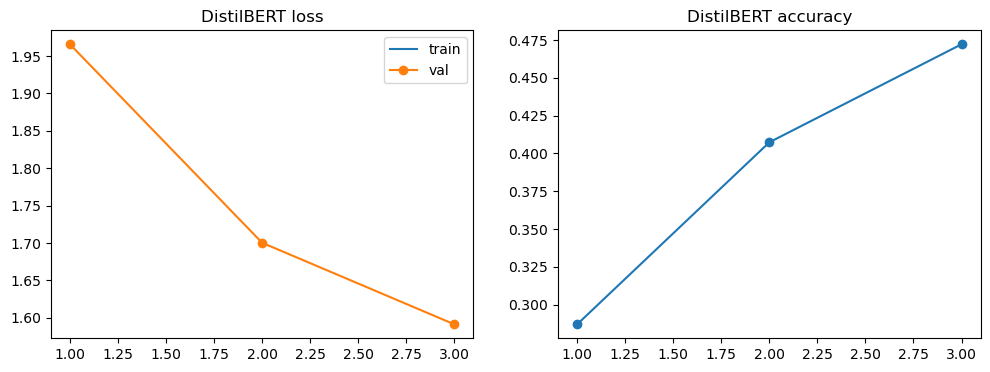

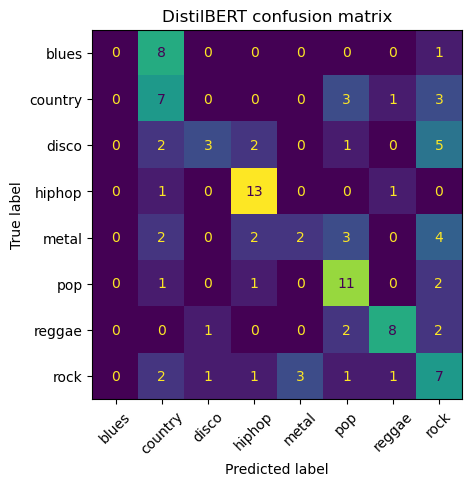

In [ ]:
import torch

# Execution Pipeline
bert_clf = DistilBERTClassifier(cfg)
bert_clf.train(dm.train_df, dm.val_df)

# Inference processing block
val_ds = bert_clf._build_hf_dataset(dm.val_df)
logits = bert_clf.trainer.predict(val_ds).predictions
bert_val_proba = torch.softmax(torch.tensor(logits, dtype=torch.float32), dim=-1).numpy()
bert_val_preds = np.argmax(bert_val_proba, axis=1)
bert_val_acc = float(np.mean(bert_val_preds == dm.val_df['label'].values))
print("DistilBERT val accuracy:", bert_val_acc)

# Plot history extraction
logs = bert_clf.trainer.state.log_history
train_logs = [l for l in logs if 'loss' in l and 'eval_loss' not in l]
eval_logs = [l for l in logs if 'eval_loss' in l]
steps_per_epoch = max(1, bert_clf.trainer.state.max_steps / BERT_EPOCHS)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

if train_logs:
    ax1.plot(
        [l['step'] / steps_per_epoch for l in train_logs],
        [l['loss'] for l in train_logs],
        label='train'
    )

ax1.plot([l['epoch'] for l in eval_logs], [l['eval_loss'] for l in eval_logs], marker='o', label='val')
ax1.set_title('DistilBERT loss')
ax1.legend()
ax2.plot([l['epoch'] for l in eval_logs], [l.get('eval_accuracy', 0) for l in eval_logs], marker='o', label='val')
ax2.set_title('DistilBERT accuracy')
plt.show()

genre_labels = [cfg.IDX_TO_GENRE[i] for i in range(8)]
plot_cm(dm.val_df['label'].values, bert_val_preds, 'DistilBERT confusion matrix', genre_labels)

# 6. Model of Choice:

Voor opdracht 6 is gekozen voor een ensemblemodel dat audiofeatures combineert met songteksten. Het audiomodel gebruikt GRU-lagen op mel spectrogrammen, terwijl voor de lyrics gebruik is gemaakt van transfer learning met DistilBERT.

DistilBERT is gekozen omdat vooraf getrainde transformers doorgaans betere tekstrepresentaties leren dan traditionele LSTM-modellen. Voor audio is gekozen voor een relatief klein GRU-model om overfitting te beperken en trainingstijd laag te houden.

De voorspellingen van beide modellen worden gecombineerd met soft voting. Hierbij krijgt het tekstmodel iets meer gewicht (0.6) omdat dit model tijdens validatie betere prestaties behaalde dan het audiomodel.

In [ ]:

import torch
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from sklearn.metrics import accuracy_score

tf.random.set_seed(cfg.SEED)
np.random.seed(cfg.SEED)
extractor = AudioFeatureExtractor(cfg)

X_audio_train = extractor.build_dataset(dm.train_df)
X_audio_val = extractor.build_dataset(dm.val_df)

y_train = dm.train_df['label'].values
y_val = dm.val_df['label'].values


audio_model = keras.Sequential([
    layers.Input(shape=(MAX_FRAMES, N_MELS)),
    layers.GRU(128, return_sequences=True),
    layers.GRU(64),
    layers.Dense(64, activation='relu'),
    layers.Dropout(0.3),
    layers.Dense(8, activation='softmax')
])

audio_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

history_audio = audio_model.fit(
    X_audio_train,
    y_train,
    validation_data=(X_audio_val, y_val),
    epochs=15,
    batch_size=16,
    callbacks=[
        keras.callbacks.EarlyStopping(
            monitor='val_loss',
            patience=3,
            restore_best_weights=True
        )
    ],
    verbose=1
)


bert_clf = DistilBERTClassifier(cfg)
bert_clf.train(dm.train_df, dm.val_df)


audio_val_proba = audio_model.predict(X_audio_val, verbose=0)

val_ds = bert_clf._build_hf_dataset(dm.val_df)
bert_logits = bert_clf.trainer.predict(val_ds).predictions

bert_val_proba = torch.softmax(
    torch.tensor(bert_logits, dtype=torch.float32),
    dim=-1
).numpy()

ensemble_proba = (
    0.4 * audio_val_proba +
    0.6 * bert_val_proba
)

ensemble_preds = np.argmax(ensemble_proba, axis=1)

ensemble_acc = accuracy_score(y_val, ensemble_preds)

print("Ensemble validation accuracy:", ensemble_acc)

genre_labels = [cfg.IDX_TO_GENRE[i] for i in range(8)]

plot_history(history_audio, 'Audio GRU Ensemble')
plot_cm(
    y_val,
    ensemble_preds,
    'Ensemble confusion matrix',
    genre_labels
)

audio_model.summary()

In [ ]:
test_df = pd.read_csv(cfg.TEST_CSV)

X_audio_test = extractor.build_dataset(
    test_df,
    is_test=True
)

audio_test_proba = audio_model.predict(
    X_audio_test,
    verbose=0
)

test_ds = bert_clf._build_hf_dataset(
    test_df.assign(label=0)
)

bert_test_logits = bert_clf.trainer.predict(
    test_ds
).predictions

bert_test_proba = torch.softmax(
    torch.tensor(bert_test_logits, dtype=torch.float32),
    dim=-1
).numpy()

test_proba = (
    0.4 * audio_test_proba +
    0.6 * bert_test_proba
)

test_preds = np.argmax(test_proba, axis=1)

submission = pd.DataFrame({
    'filename': test_df['filename'],
    'genre': [cfg.IDX_TO_GENRE[p] for p in test_preds]
})

submission.to_csv('submission_ensemble.csv', index=False)

print(submission.head())

# 7. Findings and Conclusion:

## Opdracht 7 Conclusie en Aanbevelingen

### Modelleringsproces en uitdagingen

We zijn begonnen met een EDA om de dataset te begrijpen, daarna zijn we het audiomodel gaan bouwen, vervolgens de tekstmodellen en tot slot hebben we alles gecombineerd in een ensemblemodel.

De grootste uitdaging was gewoon de dataset zelf. Met maar 429 trainingssamples verdeeld over 8 genres zijn dat gemiddeld zo'n 54 samples per genre, wat erg weinig is voor deep learning. Dit zorgde bij elk model voor overfitting. Daarbij was er ook nog klasse onbalans: rock, pop en hiphop hadden veel meer samples dan blues. Dat zagen we meteen terug in de voorspellingen van het GRU model, dat de eerste keer bijna alles als hiphop labelde. DistilBERT trainen kostte ook veel meer tijd en geheugen dan de andere modellen, wat het experimenteren iets trager maakte.

### Wat werkte wel en wat niet?

Het meest opvallende verschil was tussen het LSTM model en DistilBERT, terwijl beide op lyrics werken. Het LSTM haalde maar ~30% accuracy en voorspelde veel genres foutief als blues of hiphop. Het probleem was niet de architectuur zelf maar het feit dat het model de embeddings helemaal zelf moest leren op basis van maar 429 samples. Dat is gewoon te weinig.

DistilBERT deed het met ~58% al veel beter, omdat het al voorgetraind is op enorme hoeveelheden tekst. Die voorkennis maakt een groot verschil op een kleine dataset.

Voor audio haalde het GRU-model ~40%. Dat is beter dan het LSTM op tekst, maar nog steeds niet hoog. Na het toevoegen van class weights verbeterde de spreiding van voorspellingen wel duidelijk: de bias richting hiphop verminderde. Metal en blues werden het betrouwbaarst herkend, terwijl disco en reggae veel vaker verward werden.

Het ensemble van GRU + DistilBERT gaf uiteindelijk de beste resultaten, wat logisch is omdat de twee modaliteiten elkaar aanvullen.

### Beste modellen per modaliteit

Voor **audio** was het GRU model het enige dat we hebben getest, en dat haalde ~40%. Dat is redelijk gezien de kleine dataset, maar er is zeker ruimte voor verbetering.

Voor **tekst** was DistilBERT veruit de beste optie met ~58%. Het was als enige in staat om alle acht genres tenminste een keer correct te voorspellen in de confusion matrix. Het LSTM bleef bij ~30% en was dus eigenlijk niet bruikbaar voor dit probleem.

### Welke genres waren makkelijker te voorspellen?

**Met audio:**
Metal was het makkelijkst te herkennen. In de spectrogrammen zag je meteen het dichte, verzadigde patroon met veel energie over bijna alle frequenties. Ook hiphop had een herkenbaar patroon door de regelmatige ritmische spikes in de lage frequenties.

Blues viel ook op door juist het tegenovergestelde: weinig energie in de hogere frequenties, relatief rustig spectrum.

Disco en reggae waren het moeilijkst voor het audiomodel. Die hebben allebei vergelijkbare ritmische patronen waardoor het model ze regelmatig verwisselde.

**Met lyrics:**
Hiphop had het meest onderscheidende vocabulaire, wat ook terug te zien was in de EDA. Metal ook, al was de woordenschat in onze dataset soms wat raar bijvoorbeeld natalya als top woord. Reggae had herkenbare woorden zoals jammin, wat hielp.

Rock en country bleven lastig in beide modaliteiten. Met tekst overlappen ze veel en ook in het audiodomein zijn de patronen niet ver uit elkaar.

### Advies voor een bedrijf

Als een bedrijf op basis van dit werk een app wil bouwen, zouden we eerst zeggen: zorg voor meer data. Dat was hier de grootste beperking en meer samples per genre zou alle modellen direct beter maken.

Verder denken we dat het slim is om beide modaliteiten te combineren, net zoals wij gedaan hebben. Voor tekst is een voorgetraind model zoals DistilBERT de beste keuze. Voor audio zou je in plaats van een GRU eerder kijken naar een CNN op mel spectrogrammen, dat werkt in de literatuur doorgaans beter voor audio classificatie.

Ook is het verstandig om het systeem niet blindelings alle genres te laten labelen. Als de model confidence laag is (zoals bij rock vs. country), is het beter om dat te markeren voor handmatige controle dan een foute voorspelling te geven.

### Uitbreiding naar muziekaanbeveling

Om van genre classificatie naar een aanbevelingssysteem te gaan, zou je de modellen anders gaan inzetten. In plaats van alleen de eindklasse te gebruiken, zou je de tussenliggende representaties, de embeddings, opslaan per nummer. Die embeddings vangen iets op van de inhoud van het nummer, zowel qua klank uit het GRU-model als qua tekst uit DistilBERT.

Als je die twee embeddings samenvoegt tot een vector per nummer, kun je via cosinus similariteit zoeken welke nummers het meest op elkaar lijken. Nummers die dicht bij elkaar liggen in die vectorruimte zouden dan met stijl en tekst vergelijkbaar moeten zijn.

Dit is een content based aanpak. Om het echt personaliseren, zoals Spotify doet, zou je dit combineren met luistergedrag van gebruikers welke nummers iemand vaker afspeelt, skipt, etc. Dat noemen we collaborative filtering. De combinatie van beide levert het beste resultaat.